In [2]:
import pandas as pd
import numpy as np
import numpy.random as rand
import scipy.stats
import matplotlib as mpl
import matplotlib.pyplot as plt

In [ ]:
# In terminal
cd /scratch/humgen551w26_class_root/humgen551w26_class/shared_data/group4/

# Download fastq files from SRA
fasterq-dump SRR21012525 -O /scratch/humgen551w26_class_root/humgen551w26_class/shared_data/group4/
fasterq-dump SRR21012526 -O /scratch/humgen551w26_class_root/humgen551w26_class/shared_data/group4/
fasterq-dump SRR21012529 -O /scratch/humgen551w26_class_root/humgen551w26_class/shared_data/group4/
fasterq-dump SRR21012530 -O /scratch/humgen551w26_class_root/humgen551w26_class/shared_data/group4/

fasterq-dump SRR21012527 -O /scratch/humgen551w26_class_root/humgen551w26_class/shared_data/group4/
fasterq-dump SRR21012528 -O /scratch/humgen551w26_class_root/humgen551w26_class/shared_data/group4/
fasterq-dump SRR21012531 -O /scratch/humgen551w26_class_root/humgen551w26_class/shared_data/group4/
fasterq-dump SRR21012532 -O /scratch/humgen551w26_class_root/humgen551w26_class/shared_data/group4/

In [ ]:
# Take a look at one of the files (in terminal)
head SRR21012525.fastq 

#@SRR21012525.1 NB502099:46:H53JCBGX3:1:11101:12040:1052 length=151
#TTCATNTATAGGACAAATACTTTATTTCCANNTNTTTAANAAATATACCATTTTTTTGCTGTGAACTTTCCCAGTAAATTTCTTTTGTACCCATTAGTATTAGAATAATGTTATCTTGTGCGATTGTTAAAACCCTGTTTTATTCCCAGTT
#+SRR21012525.1 NB502099:46:H53JCBGX3:1:11101:12040:1052 length=151
#AAAAA#EEEEEEEEEEEEEEEEEEEEEAAE##E#EEEEE#EEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEAEEEAEEEAEEE/EEE/<EEEEEEEAEEEEAEEEEE/E/EEEEEE<EEEEEEEEE/<EEEEEEAEAE<EEEA6EAAEEEA
#@SRR21012525.2 NB502099:46:H53JCBGX3:1:11101:7214:1053 length=151
#GCTATNATGTGTCTTTAAGAGTTTGCCTCANNTNTCACAGGTTCATCATCTTGTATGAACTTCTTTAGTAATATTTGTGTGTAATACTCAGAGATTTTTTTTTTTTTTGGTTTTTGTTTTCATAGATTAGAAATGTGTTTACAATCTCCGT
#+SRR21012525.2 NB502099:46:H53JCBGX3:1:11101:7214:1053 length=151
#AAAAA#EEEEEEEEEEEEEEEEEEEEEEEE##E#EEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEAEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEAEEEEE//AEE/E/EEE</E/A/EEE//EAE//A/EEE//A<//<<</<
#@SRR21012525.3 NB502099:46:H53JCBGX3:1:11101:11809:1056 length=150
#GAGCANAGACCTGCTGTTCATCTTGACTGCTAAATACAATGCCTGTATCTTGGAGTATAAGCAGAGTGGCGAAAGCATTGACATCATTACAAGAGCCCATGGCAATGTCCAGGACCGCATTGGTCGCCCCTCGGAGACTGGCATCATTGG

In [ ]:
# Estimate gene abundance for each sample using kallisto (in terminal)
module load Bioinformatics
module load kallisto/0.46.0

# Generate index of mouse transcriptome from Gencode
wget -c https://ftp.ebi.ac.uk/pub/databases/gencode/Gencode_mouse/release_M35/gencode.vM35.transcripts.fa.gz
gunzip gencode.vM35.transcripts.fa.gz
kallisto index -i gencode_vM35.index gencode.vM35.transcripts.fa

# Generate gene counts for each sample 
    # --single = single-end reads
    # -l = average fragment length (usually around 200-300bp)
    # -s = standard deviation of fragment length (usually around 20-30)
kallisto quant --plaintext --single -l 200 -s 20 -i /scratch/humgen551w26_class_root/humgen551w26_class/shared_data/group4/gencode_vM35.index -o Acute_1_SRR21012525 SRR21012525.fastq
kallisto quant --plaintext --single -l 200 -s 20 -i /scratch/humgen551w26_class_root/humgen551w26_class/shared_data/group4/gencode_vM35.index -o Acute_2_SRR21012526 SRR21012526.fastq
kallisto quant --plaintext --single -l 200 -s 20 -i /scratch/humgen551w26_class_root/humgen551w26_class/shared_data/group4/gencode_vM35.index -o Acute_3_SRR21012529 SRR21012529.fastq
kallisto quant --plaintext --single -l 200 -s 20 -i /scratch/humgen551w26_class_root/humgen551w26_class/shared_data/group4/gencode_vM35.index -o Acute_4_SRR21012530 SRR21012530.fastq

kallisto quant --plaintext --single -l 200 -s 20 -i /scratch/humgen551w26_class_root/humgen551w26_class/shared_data/group4/gencode_vM35.index -o Chronic_1_SRR21012527 SRR21012527.fastq
kallisto quant --plaintext --single -l 200 -s 20 -i /scratch/humgen551w26_class_root/humgen551w26_class/shared_data/group4/gencode_vM35.index -o Chronic_2_SRR21012528 SRR21012528.fastq
kallisto quant --plaintext --single -l 200 -s 20 -i /scratch/humgen551w26_class_root/humgen551w26_class/shared_data/group4/gencode_vM35.index -o Chronic_3_SRR21012531 SRR21012531.fastq
kallisto quant --plaintext --single -l 200 -s 20 -i /scratch/humgen551w26_class_root/humgen551w26_class/shared_data/group4/gencode_vM35.index -o Chronic_4_SRR21012532 SRR21012532.fastq


# The resulting output will include TPM estimates for each transcript target.

In [93]:
# Read in the kallisto data

Acute_1 = pd.read_csv('/scratch/humgen551w26_class_root/humgen551w26_class/shared_data/group4/Acute/Acute_1_SRR21012525/abundance.tsv', sep="\t")
Acute_2 = pd.read_csv('/scratch/humgen551w26_class_root/humgen551w26_class/shared_data/group4/Acute/Acute_2_SRR21012526/abundance.tsv', sep="\t")
Acute_3 = pd.read_csv('/scratch/humgen551w26_class_root/humgen551w26_class/shared_data/group4/Acute/Acute_3_SRR21012529/abundance.tsv', sep="\t")
Acute_4 = pd.read_csv('/scratch/humgen551w26_class_root/humgen551w26_class/shared_data/group4/Acute/Acute_4_SRR21012530/abundance.tsv', sep="\t")

Chronic_1 = pd.read_csv('/scratch/humgen551w26_class_root/humgen551w26_class/shared_data/group4/Chronic/Chronic_1_SRR21012527/abundance.tsv', sep="\t")
Chronic_2 = pd.read_csv('/scratch/humgen551w26_class_root/humgen551w26_class/shared_data/group4/Chronic/Chronic_2_SRR21012528/abundance.tsv', sep="\t")
Chronic_3 = pd.read_csv('/scratch/humgen551w26_class_root/humgen551w26_class/shared_data/group4/Chronic/Chronic_3_SRR21012531/abundance.tsv', sep="\t")
Chronic_4 = pd.read_csv('/scratch/humgen551w26_class_root/humgen551w26_class/shared_data/group4/Chronic/Chronic_4_SRR21012532/abundance.tsv', sep="\t")


# Split up the target_id column since theres a ton of columns combined into one (separated by |)
Acute_1[['transcript_id', 'gene_id', 'idk', 'idk2', 'transcript_name', 'gene_name', 'transcript_length', 'type', 'extra']] = Acute_1['target_id'].str.split('|', expand=True)
Acute_2[['transcript_id', 'gene_id', 'idk', 'idk2', 'transcript_name', 'gene_name', 'transcript_length', 'type', 'extra']] = Acute_2['target_id'].str.split('|', expand=True)
Acute_3[['transcript_id', 'gene_id', 'idk', 'idk2', 'transcript_name', 'gene_name', 'transcript_length', 'type', 'extra']] = Acute_3['target_id'].str.split('|', expand=True)
Acute_4[['transcript_id', 'gene_id', 'idk', 'idk2', 'transcript_name', 'gene_name', 'transcript_length', 'type', 'extra']] = Acute_4['target_id'].str.split('|', expand=True)

Chronic_1[['transcript_id', 'gene_id', 'idk', 'idk2', 'transcript_name', 'gene_name', 'transcript_length', 'type', 'extra']] = Chronic_1['target_id'].str.split('|', expand=True)
Chronic_2[['transcript_id', 'gene_id', 'idk', 'idk2', 'transcript_name', 'gene_name', 'transcript_length', 'type', 'extra']] = Chronic_2['target_id'].str.split('|', expand=True)
Chronic_3[['transcript_id', 'gene_id', 'idk', 'idk2', 'transcript_name', 'gene_name', 'transcript_length', 'type', 'extra']] = Chronic_3['target_id'].str.split('|', expand=True)
Chronic_4[['transcript_id', 'gene_id', 'idk', 'idk2', 'transcript_name', 'gene_name', 'transcript_length', 'type', 'extra']] = Chronic_4['target_id'].str.split('|', expand=True)


In [4]:
Acute_1

,target_id,length,eff_length,est_counts,tpm,transcript_id,gene_id,idk,idk2,transcript_name,gene_name,transcript_length,type,extra
0,ENSMUST00000193812.2|ENSMUSG00000102693.2|OTTM...,1070,871.00000,0.0,0.000,ENSMUST00000193812.2,ENSMUSG00000102693.2,OTTMUSG00000049935.1,OTTMUST00000127109.1,4933401J01Rik-201,4933401J01Rik,1070,TEC,
1,ENSMUST00000082908.3|ENSMUSG00000064842.3|-|-|...,110,4.62459,0.0,0.000,ENSMUST00000082908.3,ENSMUSG00000064842.3,-,-,Gm26206-201,Gm26206,110,snRNA,
2,ENSMUST00000162897.2|ENSMUSG00000051951.6|OTTM...,4153,3954.00000,0.0,0.000,ENSMUST00000162897.2,ENSMUSG00000051951.6,OTTMUSG00000026353.2,OTTMUST00000086625.1,Xkr4-203,Xkr4,4153,protein_coding_CDS_not_defined,
3,ENSMUST00000159265.2|ENSMUSG00000051951.6|OTTM...,2989,2790.00000,0.0,0.000,ENSMUST00000159265.2,ENSMUSG00000051951.6,OTTMUSG00000026353.2,OTTMUST00000086624.1,Xkr4-202,Xkr4,2989,protein_coding_CDS_not_defined,
4,ENSMUST00000070533.5|ENSMUSG00000051951.6|OTTM...,3634,3435.00000,0.0,0.000,ENSMUST00000070533.5,ENSMUSG00000051951.6,OTTMUSG00000026353.2,OTTMUST00000065166.1,Xkr4-201,Xkr4,3634,protein_coding,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149133,ENSMUST00000082419.1|ENSMUSG00000064368.1|-|-|...,519,320.00000,675.0,483.823,ENSMUST00000082419.1,ENSMUSG00000064368.1,-,-,mt-Nd6-201,mt-Nd6,519,protein_coding,
149134,ENSMUST00000082420.1|ENSMUSG00000064369.1|-|-|...,69,3.46281,0.0,0.000,ENSMUST00000082420.1,ENSMUSG00000064369.1,-,-,mt-Te-201,mt-Te,69,Mt_tRNA,
149135,ENSMUST00000082421.1|ENSMUSG00000064370.1|-|-|...,1144,945.00000,8983.0,2180.330,ENSMUST00000082421.1,ENSMUSG00000064370.1,-,-,mt-Cytb-201,mt-Cytb,1144,protein_coding,
149136,ENSMUST00000082422.1|ENSMUSG00000064371.1|-|-|...,67,3.42238,0.0,0.000,ENSMUST00000082422.1,ENSMUSG00000064371.1,-,-,mt-Tt-201,mt-Tt,67,Mt_tRNA,


In [94]:
# Change count and tpm column names to be unique
Acute_1 = Acute_1.rename(columns={'est_counts': 'Acute_1_counts'})
Acute_2 = Acute_2.rename(columns={'est_counts': 'Acute_2_counts'})
Acute_3 = Acute_3.rename(columns={'est_counts': 'Acute_3_counts'})
Acute_4 = Acute_4.rename(columns={'est_counts': 'Acute_4_counts'})

Chronic_1 = Chronic_1.rename(columns={'est_counts': 'Chronic_1_counts'})
Chronic_2 = Chronic_2.rename(columns={'est_counts': 'Chronic_2_counts'})
Chronic_3 = Chronic_3.rename(columns={'est_counts': 'Chronic_3_counts'})
Chronic_4 = Chronic_4.rename(columns={'est_counts': 'Chronic_4_counts'})

Acute_1 = Acute_1.rename(columns={'tpm': 'Acute_1_kallisto'})
Acute_2 = Acute_2.rename(columns={'tpm': 'Acute_2_kallisto'})
Acute_3 = Acute_3.rename(columns={'tpm': 'Acute_3_kallisto'})
Acute_4 = Acute_4.rename(columns={'tpm': 'Acute_4_kallisto'})

Chronic_1 = Chronic_1.rename(columns={'tpm': 'Chronic_1_kallisto'})
Chronic_2 = Chronic_2.rename(columns={'tpm': 'Chronic_2_kallisto'})
Chronic_3 = Chronic_3.rename(columns={'tpm': 'Chronic_3_kallisto'})
Chronic_4 = Chronic_4.rename(columns={'tpm': 'Chronic_4_kallisto'})



# Select just gene name, counts, and tpm columns
Acute_1 = Acute_1.iloc[:, [4, 10]]   
Acute_2 = Acute_2.iloc[:, [4, 10]]   
Acute_3 = Acute_3.iloc[:, [4, 10]]   
Acute_4 = Acute_4.iloc[:, [4, 10]]   

Chronic_1 = Chronic_1.iloc[:, [4, 10]]   
Chronic_2 = Chronic_2.iloc[:, [4, 10]]   
Chronic_3 = Chronic_3.iloc[:, [4, 10]]   
Chronic_4 = Chronic_4.iloc[:, [4, 10]]  



# Set index as gene_name
Acute_1 = Acute_1.set_index('gene_name')
Acute_2 = Acute_2.set_index('gene_name')
Acute_3 = Acute_3.set_index('gene_name')
Acute_4 = Acute_4.set_index('gene_name')

Chronic_1 = Chronic_1.set_index('gene_name')
Chronic_2 = Chronic_2.set_index('gene_name')
Chronic_3 = Chronic_3.set_index('gene_name')
Chronic_4 = Chronic_4.set_index('gene_name')

In [95]:
Acute_1

,Acute_1_kallisto
gene_name,
4933401J01Rik,0.000
Gm26206,0.000
Xkr4,0.000
Xkr4,0.000
Xkr4,0.000
...,...
mt-Nd6,483.823
mt-Te,0.000
mt-Cytb,2180.330


In [96]:
# Merge all samples into one dataframe

merged_data = pd.concat([Acute_1, Acute_2, Acute_3, Acute_4, Chronic_1, Chronic_2, Chronic_3, Chronic_4], axis = 1)  # axis=1 means to combine columns
merged_data

,Acute_1_kallisto,Acute_2_kallisto,Acute_3_kallisto,Acute_4_kallisto,Chronic_1_kallisto,Chronic_2_kallisto,Chronic_3_kallisto,Chronic_4_kallisto
gene_name,,,,,,,,
4933401J01Rik,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
Gm26206,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
Xkr4,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
Xkr4,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
Xkr4,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
...,...,...,...,...,...,...,...,...
mt-Nd6,483.823,470.655,425.228,490.328,298.389,230.916,248.802,291.717
mt-Te,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
mt-Cytb,2180.330,1994.490,2147.960,1938.160,1917.510,1934.060,1971.460,1806.280


In [201]:
# Log2 transform the tpm data
merged_data_log = np.log2(merged_data + 1)

# Merge duplicate genes in our data
merged_data_log = merged_data_log.reset_index().rename(columns={'index': 'gene_name'})
merged_data_log = merged_data_log.groupby('gene_name', as_index=False).mean()
merged_data_log = merged_data_log.set_index('gene_name')

# Remove rows with all zeros
merged_data_log = merged_data_log[merged_data_log.sum(axis=1) != 0]
merged_data_log

,Acute_1_kallisto,Acute_2_kallisto,Acute_3_kallisto,Acute_4_kallisto,Chronic_1_kallisto,Chronic_2_kallisto,Chronic_3_kallisto,Chronic_4_kallisto
gene_name,,,,,,,,
0610005C13Rik,0.008809,0.005513,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
0610009E02Rik,0.240245,0.099595,0.045360,0.000000,0.000000,0.000000,0.032932,0.128414
0610009L18Rik,0.527054,0.653785,0.425870,0.698361,0.174405,0.204339,0.429697,0.000000
0610010K14Rik,1.554577,1.772031,1.990328,1.784435,1.514277,1.755344,1.548385,2.005926
0610030E20Rik,1.364446,1.331310,1.187856,1.146170,1.149702,0.878875,1.088483,0.974574
...,...,...,...,...,...,...,...,...
mt-Nd4l,8.459731,8.225130,8.291797,8.402888,8.133024,7.665300,7.940049,7.682236
mt-Nd5,8.877505,8.734821,8.861155,8.745910,8.176432,8.180456,8.159331,8.135124
mt-Nd6,8.921314,8.881588,8.735482,8.940543,8.225877,7.857459,7.964641,8.193363


In [202]:
# Look at an example "Exhaustion" gene (should be higher in Chronic samples)
merged_data_log_gene = merged_data_log.loc['Pdcd1']
merged_data_log_gene

Acute_1_kallisto      4.561894
Acute_2_kallisto      4.467899
Acute_3_kallisto      4.270110
Acute_4_kallisto      4.523480
Chronic_1_kallisto    7.647322
Chronic_2_kallisto    7.718266
Chronic_3_kallisto    7.770162
Chronic_4_kallisto    7.624810
Name: Pdcd1, dtype: float64

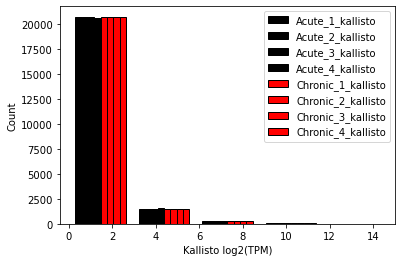

In [243]:
# Make a histogram of the log2(tpm) counts for each sample
# Assign colors to each group
colors = ['black', 'black', 'black', 'black', 'red', 'red', 'red', 'red']
_ = plt.hist(merged_data_log, bins=5, label=merged_data_log.columns, color = colors, edgecolor='black')
_ = plt.xlabel('Kallisto log2(TPM)')
_ = plt.ylabel('Count')
_ = plt.legend()

In [204]:
## PCA PLOT
# Input is log2(tpm) data with samples in rows

# First, transpose columns into rows
merged_data_transposed = merged_data_log.T
merged_data_transposed

gene_name,0610005C13Rik,0610009E02Rik,0610009L18Rik,0610010K14Rik,0610030E20Rik,0610033M10Rik,0610038B21Rik,0610039K10Rik,0610040B10Rik,0610040F04Rik,...,mt-Cytb,mt-Nd1,mt-Nd2,mt-Nd3,mt-Nd4,mt-Nd4l,mt-Nd5,mt-Nd6,mt-Rnr1,mt-Rnr2
Acute_1_kallisto,0.008809,0.240245,0.527054,1.554577,1.364446,0.163273,0.113305,0.200227,0.111293,0.367690,...,11.090992,10.907394,8.247491,8.947204,9.360186,8.459731,8.877505,8.921314,7.479675,10.985251
Acute_2_kallisto,0.005513,0.099595,0.653785,1.772031,1.331310,0.000000,0.000000,0.522731,0.194910,0.245459,...,10.962527,10.748394,8.074227,8.985475,9.196477,8.225130,8.734821,8.881588,7.278635,10.768118
Acute_3_kallisto,0.000000,0.045360,0.425870,1.990328,1.187856,0.000000,0.089383,0.606652,0.279322,0.000000,...,11.069423,10.922570,8.100010,8.976830,9.360566,8.291797,8.861155,8.735482,7.296916,10.864116
Acute_4_kallisto,0.000000,0.000000,0.698361,1.784435,1.146170,0.000000,0.095469,0.657087,0.217046,0.000000,...,10.921216,10.709592,8.144541,8.869202,9.192616,8.402888,8.745910,8.940543,7.208459,10.819604
Chronic_1_kallisto,0.000000,0.000000,0.174405,1.514277,1.149702,0.000000,0.124945,0.265083,0.244553,0.000000,...,10.905771,11.320896,8.249076,9.619376,8.654869,8.133024,8.176432,8.225877,6.891735,10.321984
Chronic_2_kallisto,0.000000,0.000000,0.204339,1.755344,0.878875,0.000000,0.039675,0.259657,0.036545,0.262033,...,10.918163,11.206379,8.063719,9.357886,8.528872,7.665300,8.180456,7.857459,6.857135,10.153932
Chronic_3_kallisto,0.000000,0.032932,0.429697,1.548385,1.088483,0.000000,0.000000,0.397920,0.023760,0.000000,...,10.945780,11.157296,7.906500,9.169519,8.473961,7.940049,8.159331,7.964641,6.791124,10.035775
Chronic_4_kallisto,0.000000,0.128414,0.000000,2.005926,0.974574,0.000000,0.000000,0.169746,0.269415,0.000000,...,10.819604,11.022631,8.032398,9.429721,8.343226,7.682236,8.135124,8.193363,6.909641,10.347920


In [225]:
# Scale data

from sklearn.preprocessing import StandardScaler
scaled_data = StandardScaler().fit_transform(merged_data_transposed)

In [226]:
# Run PCA

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_results = pca.fit_transform(scaled_data)

# Make dataframe with PCA values for plotting
pca_df = pd.DataFrame(data=pca_results, columns=['PC1', 'PC2'])

pca_df

,PC1,PC2
0,91.508568,-89.648528
1,75.955700,-47.264161
2,77.595936,11.992538
3,97.839677,117.528434
4,-82.123808,-3.779439
5,-82.024279,4.953611
6,-87.828447,8.184149
7,-90.923347,-1.966605


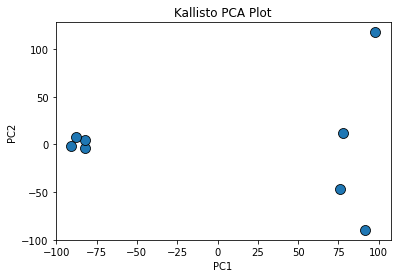

In [269]:
# Generate PCA plot
_ = plt.scatter(pca_df['PC1'], pca_df['PC2'], s=100, edgecolors='black', linewidths=0.8)
_ = plt.xlabel('PC1')
_ = plt.ylabel('PC2')
_ = plt.title('Kallisto PCA Plot')

In [270]:
# Color samples by group in PCA plot

# Since the PCA calculation deletes the sample identity, make a new df that contains the sample names and group labels 
# These labels will be added back after PCA
labels = merged_data_transposed.copy()
labels['group'] = ['Acute', 'Acute', 'Acute', 'Acute', 'Chronic', 'Chronic', 'Chronic', 'Chronic']

# Select just 'group' column
labels = labels['group']
labels

Acute_1_kallisto        Acute
Acute_2_kallisto        Acute
Acute_3_kallisto        Acute
Acute_4_kallisto        Acute
Chronic_1_kallisto    Chronic
Chronic_2_kallisto    Chronic
Chronic_3_kallisto    Chronic
Chronic_4_kallisto    Chronic
Name: group, dtype: object

In [271]:
# Add labels back to PCA df
pca_df['group'] = labels.values
pca_df

# Assign colors to each group
colors = {"Acute": "black", "Chronic": "red"}
pca_df['color'] = pca_df['group'].map(colors)
pca_df

,PC1,PC2,group,color
0,91.508568,-89.648528,Acute,black
1,75.955700,-47.264161,Acute,black
2,77.595936,11.992538,Acute,black
3,97.839677,117.528434,Acute,black
4,-82.123808,-3.779439,Chronic,red
5,-82.024279,4.953611,Chronic,red
6,-87.828447,8.184149,Chronic,red
7,-90.923347,-1.966605,Chronic,red


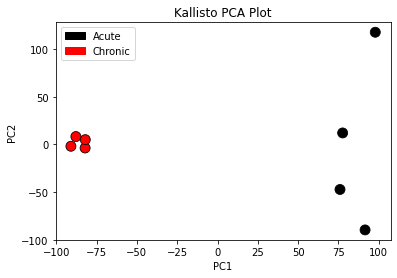

In [272]:
# Generate color PCA plot

# Hand-assign legend colors (thanks stack overflow)
import matplotlib.patches as mpatches
Acute = mpatches.Patch(color='black', label='Acute')
Chronic = mpatches.Patch(color='red', label='Chronic')

_ = plt.scatter(pca_df['PC1'], pca_df['PC2'], color=pca_df['color'], s=100, edgecolors='black', linewidths=0.8)
_ = plt.xlabel('PC1')
_ = plt.ylabel('PC2')
_ = plt.title('Kallisto PCA Plot')
_ = plt.legend(handles=[Acute, Chronic])

In [273]:
## HEATMAP
# Input is log2(tpm) zscore data

import seaborn as sns

# Select the top 1000 expressed genes across all samples 
# Order rows in descending order of the mean values
select_genes = merged_data_log.mean(axis=1).sort_values(ascending=False).head(1000).index
heatmap_data = merged_data_log.loc[select_genes]

# Convert pandas df to numpy for calculations
heatmap_data = heatmap_data.to_numpy()

# Scale genes by z-score
# First calculate mean and standard dev
mean = heatmap_data.mean(axis=1, keepdims=True)
sd = heatmap_data.std(axis=1, keepdims=True)

# Calculate zscore
heatmap_zscore = (heatmap_data - mean) / sd

# Convert zscores back into dataframe for heatmap
heatmap_zscore = pd.DataFrame(heatmap_zscore, index=select_genes, columns=merged_data_log.columns)
heatmap_zscore

,Acute_1_kallisto,Acute_2_kallisto,Acute_3_kallisto,Acute_4_kallisto,Chronic_1_kallisto,Chronic_2_kallisto,Chronic_3_kallisto,Chronic_4_kallisto
gene_name,,,,,,,,
Gzmb,-0.938887,-0.972725,-1.025178,-1.060448,0.975076,0.976670,1.028884,1.016609
mt-Co3,1.325326,0.761744,1.479836,-0.528168,-1.241710,0.020326,-0.889518,-0.927838
mt-Atp6,1.150946,0.678383,1.507981,0.006909,0.027515,-1.082398,-0.872461,-1.416875
mt-Atp8,1.450394,-0.158478,1.476688,0.626150,-0.499677,-0.571306,-1.055702,-1.268069
Mir6236,0.697949,1.321119,0.451852,1.104550,-1.578947,-0.363298,-0.378127,-1.255099
...,...,...,...,...,...,...,...,...
Sra1,-0.288483,0.210990,-0.922672,-0.515786,0.043304,-0.377212,-0.640279,2.490137
Sod1,0.744826,0.535133,1.229934,0.003811,1.001426,-1.118546,-1.708344,-0.688240
Frg1,0.743589,0.971585,0.540404,1.324665,-1.273171,-1.315579,0.057917,-1.049409


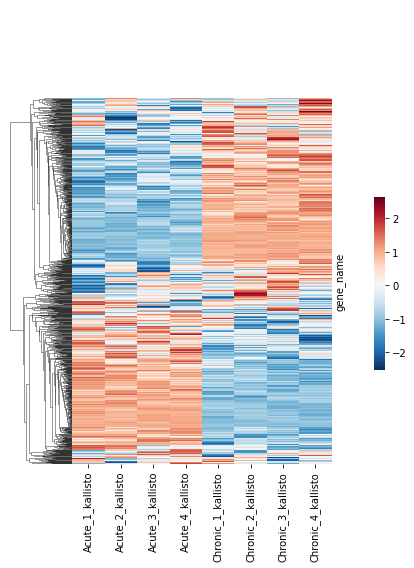

In [274]:
# Generate heatmap of top 2000 genes
g = sns.clustermap(heatmap_zscore, 
                   cmap='RdBu_r',      # Color (red to blue gradient)
                   annot=False,        # Don't show row values
                   col_cluster=False,  # Keep columns in order
                   yticklabels=False,   # Don't show row gene_name
                   figsize=(5,8))

g.ax_cbar.set_position((1.05, 0.35, .03, .3))

In [230]:
## COMPARE TO PAPER
# Paper used "PORT gene-based normalization", "text file with limma-voom normalized counts for each sample"

paper_normcounts = pd.read_table('/scratch/humgen551w26_class_root/humgen551w26_class/shared_data/group4/GSE211014_JWu_RNA_normcounts.txt')

# Rename column name and set gene_name to index
paper_normcounts = paper_normcounts.rename(columns={'geneSymbol': 'gene_name'})

# Merge duplicate genes
paper_normcounts = paper_normcounts.groupby('gene_name', as_index=False).mean()
paper_normcounts

,gene_name,R.S133_S33,R.S134_S34,R.S136_S36,R.S101_S1,R.S102_S2,R.S105_S5,R.S106_S6,R.S109_S9,R.S110_S10,...,R.S129_S29,R.S130_S30,R.S119_S19,R.S120_S20,R.S123_S23,R.S124_S24,R.S127_S27,R.S128_S28,R.S131_S31,R.S132_S32
0,0610007P14Rik,6.886362,6.269585,6.288692,7.694311,7.802583,7.867994,7.874745,7.870507,7.872217,...,7.910834,8.009718,7.294347,7.492313,7.414997,7.446852,7.079123,7.113554,7.250371,7.044414
1,0610009B22Rik,3.936645,4.014371,3.729597,4.770885,4.781099,4.913804,4.760280,5.018423,4.790308,...,4.962662,4.705097,4.276902,4.765990,4.761882,4.602681,4.538577,4.359821,4.670656,4.603023
2,0610009O20Rik,3.824895,3.618552,3.923518,3.916631,3.477237,4.061036,4.225758,3.664809,4.156723,...,3.897509,4.275387,4.061932,4.198812,3.999771,4.507885,4.320579,3.884395,3.899601,3.875508
3,0610010F05Rik,2.426885,4.369436,3.639419,5.483130,5.487986,4.914798,5.053924,4.255642,4.110502,...,6.229503,6.202097,3.739026,4.255165,4.439834,4.833149,4.744951,4.550359,4.532808,4.470938
4,0610010K14Rik,4.605043,4.682856,4.308492,4.263111,4.124490,4.579495,4.876488,4.839663,4.482495,...,4.248322,3.932578,4.143351,4.001771,4.292856,4.309953,3.875185,4.200587,3.899368,4.418572
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10134,mt-Nd4,9.403943,9.512382,8.782842,5.273688,4.505532,5.524956,5.315579,5.540365,5.416388,...,7.877295,8.121796,8.795084,9.199022,8.492321,8.718672,8.538382,8.756817,8.677851,8.790559
10135,mt-Nd5,10.180086,10.416627,9.934028,6.843590,6.334261,6.787706,6.877840,7.105974,7.490432,...,8.871411,8.912676,9.711657,10.032248,9.589106,9.683218,9.428218,9.544781,9.505498,9.603374
10136,mt-Nd6,8.121153,8.089015,7.644064,4.967494,4.778681,4.875885,5.023882,5.305809,5.330999,...,6.053477,6.653499,7.310460,7.733135,7.392458,7.417373,7.227669,7.023766,7.367612,7.308443
10137,mt-Rnr1,4.986404,4.249329,4.065227,3.919119,3.277699,3.738222,4.075637,3.915234,3.989784,...,3.290945,2.981208,3.808942,4.668293,4.268556,4.093134,3.444420,3.662788,3.422110,3.971055


In [244]:
# Select the samples we are using
paper_samples = paper_normcounts[['gene_name', 'R.S125_S25', 'R.S126_S26', 'R.S129_S29', 'R.S130_S30', 'R.S127_S27', 'R.S128_S28', 'R.S131_S31', 'R.S132_S32']]

paper_samples = paper_samples.rename(columns={'R.S125_S25': 'Chronic_1_paper'})
paper_samples = paper_samples.rename(columns={'R.S126_S26': 'Chronic_2_paper'})
paper_samples = paper_samples.rename(columns={'R.S129_S29': 'Chronic_3_paper'})
paper_samples = paper_samples.rename(columns={'R.S130_S30': 'Chronic_4_paper'})

paper_samples = paper_samples.rename(columns={'R.S127_S27': 'Acute_1_paper'})
paper_samples = paper_samples.rename(columns={'R.S128_S28': 'Acute_2_paper'})
paper_samples = paper_samples.rename(columns={'R.S131_S31': 'Acute_3_paper'})
paper_samples = paper_samples.rename(columns={'R.S132_S32': 'Acute_4_paper'})

paper_samples = paper_samples.set_index('gene_name')
paper_samples = paper_samples[['Acute_1_paper', 'Acute_2_paper', 'Acute_3_paper', 'Acute_4_paper', 'Chronic_1_paper', 'Chronic_2_paper', 'Chronic_3_paper', 'Chronic_4_paper']]

paper_samples

,Acute_1_paper,Acute_2_paper,Acute_3_paper,Acute_4_paper,Chronic_1_paper,Chronic_2_paper,Chronic_3_paper,Chronic_4_paper
gene_name,,,,,,,,
0610007P14Rik,7.079123,7.113554,7.250371,7.044414,7.999627,7.775496,7.910834,8.009718
0610009B22Rik,4.538577,4.359821,4.670656,4.603023,4.826165,4.531129,4.962662,4.705097
0610009O20Rik,4.320579,3.884395,3.899601,3.875508,4.023311,3.647413,3.897509,4.275387
0610010F05Rik,4.744951,4.550359,4.532808,4.470938,6.103434,6.107004,6.229503,6.202097
0610010K14Rik,3.875185,4.200587,3.899368,4.418572,3.893976,4.205481,4.248322,3.932578
...,...,...,...,...,...,...,...,...
mt-Nd4,8.538382,8.756817,8.677851,8.790559,7.812387,7.870119,7.877295,8.121796
mt-Nd5,9.428218,9.544781,9.505498,9.603374,8.883981,8.828583,8.871411,8.912676
mt-Nd6,7.227669,7.023766,7.367612,7.308443,6.700298,6.505446,6.053477,6.653499


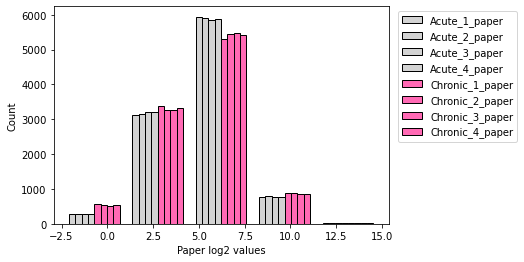

In [267]:
# Make a histogram of each sample from the paper
colors = ['lightgray', 'lightgray', 'lightgray', 'lightgray', 'hotpink', 'hotpink', 'hotpink', 'hotpink']

_ = plt.hist(paper_samples, bins=5, label=paper_samples.columns, color = colors, edgecolor='black')
_ = plt.xlabel('Paper log2 values')
_ = plt.ylabel('Count')
_ = plt.legend()
_ = plt.legend(bbox_to_anchor=(1.4, 1), loc='upper right')

# Since there negative values on the histogram, this confirms that the values are already normalized

In [154]:
# Look at an example "Exhaustion" gene (should be higher in Chronic samples)
example_gene = paper_samples.loc['Pdcd1']
example_gene

Chronic_1_paper    8.375139
Chronic_2_paper    8.483630
Chronic_3_paper    8.394283
Chronic_4_paper    8.396707
Acute_1_paper      5.234249
Acute_2_paper      5.090016
Acute_3_paper      5.005516
Acute_4_paper      5.325196
Name: Pdcd1, dtype: float64

In [216]:
## ZSCORES
# To compare our data with the paper data, we need to convert both datasets to zscores

# Convert pandas df to numpy for calculations
merged_data_log_np = merged_data_log.to_numpy()
paper_samples_np = paper_samples.to_numpy()

# Scale genes by z-score
# First calculate mean and standard dev
mean = merged_data_log_np.mean(axis=1, keepdims=True)
sd = merged_data_log_np.std(axis=1, keepdims=True)
mean_paper = paper_samples_np.mean(axis=1, keepdims=True)
sd_paper = paper_samples_np.std(axis=1, keepdims=True)

# Get rid of sd with value of 0, since it will give error in zscore calculation
sd[sd == 0] = np.nan
sd_paper[sd_paper == 0] = np.nan

# Calculate zscore
merged_data_zscore = (merged_data_log_np - mean) / sd
paper_zscore = (paper_samples_np - mean_paper) / sd_paper

# Convert zscores back into dataframe
merged_data_zscore = pd.DataFrame(merged_data_zscore, index=merged_data_log.index, columns=merged_data_log.columns)
merged_data_zscore = merged_data_zscore.dropna()
paper_zscore = pd.DataFrame(paper_zscore, index=paper_samples.index, columns=paper_samples.columns)
paper_zscore = paper_zscore.dropna()

In [217]:
## MERGE ZSCORE DATA

# Change gene_name index back to column for both datasets
merged_data_zscore_2 = merged_data_zscore.reset_index().rename(columns={'index': 'gene_name'})
paper_zscore_2 = paper_zscore.reset_index().rename(columns={'index': 'gene_name'})

# Merge paper with our data
paper_merged = pd.merge(merged_data_zscore_2, paper_zscore_2, on = 'gene_name')

# Set gene name as index
paper_merged = paper_merged.set_index('gene_name')

# Replace NA values with zero
paper_merged = paper_merged.fillna(0)

# Re-order samples
paper_merged = paper_merged[['Acute_1_paper', 'Acute_2_paper', 'Acute_3_paper', 'Acute_4_paper', 'Chronic_1_paper', 'Chronic_2_paper', 'Chronic_3_paper', 'Chronic_4_paper', 'Acute_1_kallisto', 'Acute_2_kallisto', 'Acute_3_kallisto', 'Acute_4_kallisto', 'Chronic_1_kallisto', 'Chronic_2_kallisto', 'Chronic_3_kallisto', 'Chronic_4_kallisto']]
paper_merged                        

,Acute_1_paper,Acute_2_paper,Acute_3_paper,Acute_4_paper,Chronic_1_paper,Chronic_2_paper,Chronic_3_paper,Chronic_4_paper,Acute_1_kallisto,Acute_2_kallisto,Acute_3_kallisto,Acute_4_kallisto,Chronic_1_kallisto,Chronic_2_kallisto,Chronic_3_kallisto,Chronic_4_kallisto
gene_name,,,,,,,,,,,,,,,,
0610010K14Rik,-1.072489,0.596735,-0.948440,1.714933,-0.976097,0.621835,0.841601,-0.778079,-1.034886,0.174448,1.388469,0.243430,-1.259007,0.081650,-1.069321,1.475217
0610030E20Rik,1.328855,-1.154715,0.856432,1.311393,-1.160569,-0.548616,-0.863860,0.231080,1.464511,1.248133,0.311351,0.039134,0.062202,-1.706347,-0.337570,-1.081415
1110004F10Rik,-1.233549,-0.939181,-0.876164,-0.747985,1.251400,0.276050,0.973791,1.295638,1.827811,-0.222021,0.147663,0.752181,-0.709258,-0.620061,-1.693339,0.517024
1110032F04Rik,-0.334778,-0.456399,-0.885026,-1.897932,0.645938,0.865030,1.045099,1.018068,-1.645720,-0.948239,-0.575498,-0.616735,1.050029,1.071969,0.981161,0.683032
1110038B12Rik,0.133740,-1.988793,-0.051337,-0.259600,1.472009,0.624049,0.871056,-0.801124,0.079163,-1.294035,-1.092021,0.230365,-0.989971,0.604505,0.640466,1.821528
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
mt-Nd4,0.581450,1.127180,0.929893,1.211479,-1.232355,-1.088118,-1.070191,-0.459337,1.175711,0.767353,1.176658,0.757722,-0.583635,-0.897921,-1.034890,-1.360998
mt-Nd5,0.706187,1.062678,0.942538,1.241876,-0.958292,-1.127719,-0.996735,-0.870533,1.213095,0.773407,1.162712,0.807576,-0.947300,-0.934901,-0.999998,-1.074593
mt-Nd6,0.870828,0.394327,1.197861,1.059589,-0.361585,-0.816933,-1.873138,-0.470949,1.078652,0.984739,0.639342,1.124108,-0.565367,-1.436312,-1.182931,-0.642232


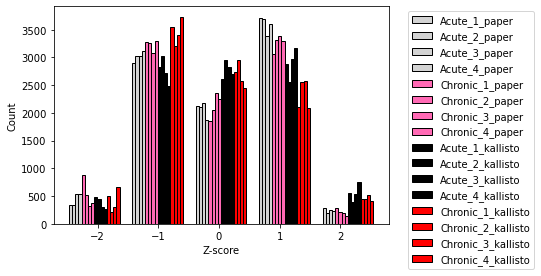

In [252]:
colors = ['lightgray', 'lightgray', 'lightgray', 'lightgray', 'hotpink', 'hotpink', 'hotpink', 'hotpink', 'black', 'black', 'black', 'black', 'red', 'red', 'red', 'red']

_ = plt.hist(paper_merged, bins=5, label=paper_merged.columns, color = colors, edgecolor='black')
_ = plt.xlabel('Z-score')
_ = plt.ylabel('Count')
_ = plt.legend(bbox_to_anchor=(1.45, 1), loc='upper right')

# Distribution of the paper & kallisto samples look more similar now

In [155]:
# Look at an example "Exhaustion" gene (should be higher in Chronic samples)
example_gene = paper_merged.loc['Pdcd1']
example_gene

Acute_1_paper        -0.955046
Acute_2_paper        -1.043696
Acute_3_paper        -1.095633
Acute_4_paper        -0.899146
Chronic_1_paper       0.975454
Chronic_2_paper       1.042136
Chronic_3_paper       0.987221
Chronic_4_paper       0.988710
Acute_1_kallisto     -0.933002
Acute_2_kallisto     -0.991038
Acute_3_kallisto     -1.113159
Acute_4_kallisto     -0.956720
Chronic_1_kallisto    0.972042
Chronic_2_kallisto    1.015846
Chronic_3_kallisto    1.047888
Chronic_4_kallisto    0.958143
Name: Pdcd1, dtype: float64

In [219]:
# MERGED PCA PLOT
# Input is log2(tpm) data with samples in rows

# First, transpose columns into rows
paper_merged_transposed = paper_merged.T
paper_merged_transposed

gene_name,0610010K14Rik,0610030E20Rik,1110004F10Rik,1110032F04Rik,1110038B12Rik,1110038F14Rik,1110059E24Rik,1110059G10Rik,1110065P20Rik,1300002E11Rik,...,Zzz3,mt-Co1,mt-Cytb,mt-Nd1,mt-Nd2,mt-Nd4,mt-Nd5,mt-Nd6,mt-Rnr1,mt-Rnr2
Acute_1_paper,-1.072489,1.328855,-1.233549,-0.334778,0.133740,1.026292,-0.915677,0.142306,-1.358426,0.408552,...,0.743581,0.722008,-0.959342,-1.624680,-0.132572,0.581450,0.706187,0.870828,-0.117305,0.689143
Acute_2_paper,0.596735,-1.154715,-0.939181,-0.456399,-1.988793,-0.732608,-0.170826,0.960596,-0.158831,1.316685,...,-0.283667,1.101379,1.009409,-0.459269,-0.317167,1.127180,1.062678,0.394327,0.649020,0.801568
Acute_3_paper,-0.948440,0.856432,-0.876164,-0.885026,-0.051337,0.115468,-1.591014,0.603565,-0.362055,0.825599,...,-1.124985,0.973171,0.786042,-0.961893,0.441735,0.929893,0.942538,1.197861,-0.195598,0.765717
Acute_4_paper,1.714933,1.311393,-0.747985,-1.897932,-0.259600,-0.166969,-1.025756,1.765050,-1.569750,0.609881,...,-0.524422,1.157892,1.836488,-0.505385,0.974399,1.211479,1.241876,1.059589,1.730830,1.373645
Chronic_1_paper,-0.976097,-1.160569,1.251400,0.645938,1.472009,1.902656,1.150346,-0.955939,1.485506,-0.351870,...,-1.396623,-1.207790,-0.848955,0.480115,0.733098,-1.232355,-0.958292,-0.361585,0.875886,-0.330158
Chronic_2_paper,0.621835,-0.548616,0.276050,0.865030,0.624049,-0.771021,0.779870,-0.231025,0.808700,-1.136298,...,1.822506,-0.965490,-0.399962,0.691216,-1.753279,-1.088118,-1.127719,-0.816933,-0.544059,-1.672371
Chronic_3_paper,0.841601,-0.863860,0.973791,1.045099,0.871056,0.091082,0.735702,-1.125975,0.635234,-1.892722,...,0.019603,-0.909048,-1.008554,0.727025,-1.222983,-1.070191,-0.996735,-1.873138,-0.655902,-1.112994
Chronic_4_paper,-0.778079,0.231080,1.295638,1.018068,-0.801124,-1.464900,1.037355,-1.158578,0.519623,0.220172,...,0.744007,-0.872122,-0.415128,1.652870,1.276769,-0.459337,-0.870533,-0.470949,-1.742871,-0.514551
Acute_1_kallisto,-1.034886,1.464511,1.827811,-1.645720,0.079163,-1.592094,-1.204875,1.390331,-1.125613,0.134321,...,1.668573,1.143404,1.650313,-0.450911,1.370047,1.175711,1.213095,1.078652,1.629137,1.320726
Acute_2_kallisto,0.174448,1.248133,-0.222021,-0.948239,-1.294035,0.246956,-1.358848,0.446054,0.257222,0.352147,...,-0.483664,0.884166,0.100639,-1.230200,-0.264284,0.767353,0.773407,0.984739,0.790435,0.680840


In [220]:
# Color samples by group in PCA plot

# Since the PCA calculation deletes the sample identity, make a new df that contains the sample names and group labels 
# These labels will be added back after PCA
paper_labels = paper_merged_transposed.copy()
paper_labels['group'] = ['Acute_paper', 'Acute_paper', 'Acute_paper', 'Acute_paper', 'Chronic_paper', 'Chronic_paper', 'Chronic_paper', 'Chronic_paper', 'Acute_kallisto', 'Acute_kallisto', 'Acute_kallisto', 'Acute_kallisto', 'Chronic_kallisto', 'Chronic_kallisto', 'Chronic_kallisto', 'Chronic_kallisto']
 
# Select just 'group' column
paper_labels = paper_labels['group']
paper_labels

Acute_1_paper              Acute_paper
Acute_2_paper              Acute_paper
Acute_3_paper              Acute_paper
Acute_4_paper              Acute_paper
Chronic_1_paper          Chronic_paper
Chronic_2_paper          Chronic_paper
Chronic_3_paper          Chronic_paper
Chronic_4_paper          Chronic_paper
Acute_1_kallisto        Acute_kallisto
Acute_2_kallisto        Acute_kallisto
Acute_3_kallisto        Acute_kallisto
Acute_4_kallisto        Acute_kallisto
Chronic_1_kallisto    Chronic_kallisto
Chronic_2_kallisto    Chronic_kallisto
Chronic_3_kallisto    Chronic_kallisto
Chronic_4_kallisto    Chronic_kallisto
Name: group, dtype: object

In [254]:
# Add labels back to PCA df
paper_pca_df['group'] = paper_labels.values
paper_pca_df

# Assign colors to each group
colors = {"Acute_paper": 'lightgray', "Chronic_paper": 'hotpink', "Acute_kallisto": "black", "Chronic_kallisto": "red"}
paper_pca_df['color'] = paper_pca_df['group'].map(colors)
paper_pca_df

,PC1,PC2,group,color
0,83.716088,43.195508,Acute_paper,lightgray
1,86.836614,41.366552,Acute_paper,lightgray
2,87.823428,38.627036,Acute_paper,lightgray
3,86.384102,38.793289,Acute_paper,lightgray
4,94.624570,-38.973351,Chronic_paper,hotpink
5,93.870111,-38.445197,Chronic_paper,hotpink
6,91.588019,-37.863944,Chronic_paper,hotpink
7,91.531138,-39.845020,Chronic_paper,hotpink
8,-89.106080,-19.533189,Acute_kallisto,black
9,-90.103421,-17.988947,Acute_kallisto,black


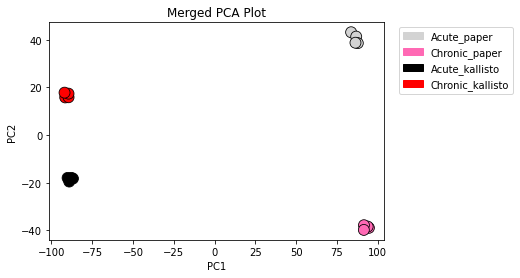

In [268]:
# Generate PCA plot

# Hand-assign legend colors
import matplotlib.patches as mpatches

Acute_paper = mpatches.Patch(color='lightgray', label='Acute_paper')
Chronic_paper = mpatches.Patch(color='hotpink', label='Chronic_paper')
Acute_kallisto = mpatches.Patch(color='black', label='Acute_kallisto')
Chronic_kallisto = mpatches.Patch(color='red', label='Chronic_kallisto')

_ = plt.scatter(paper_pca_df['PC1'], paper_pca_df['PC2'], color=paper_pca_df['color'], s=120, edgecolors='black', linewidths=0.8)
_ = plt.xlabel('PC1')
_ = plt.ylabel('PC2')
_ = plt.title('Merged PCA Plot')
_ = plt.legend(handles=[Acute_paper, Chronic_paper, Acute_kallisto, Chronic_kallisto], bbox_to_anchor=(1.4, 1), loc='upper right')

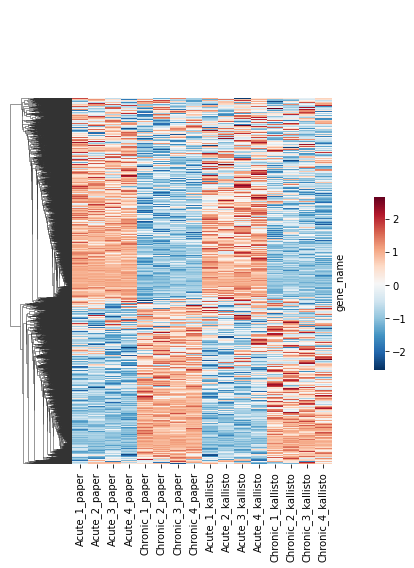

In [224]:
## MERGED HEATMAP

import seaborn as sns

# Generate heatmap of top 2000 genes
g = sns.clustermap(paper_merged, 
                   cmap='RdBu_r',      # Color (red to blue gradient)
                   annot=False,        # Don't show row values
                   col_cluster=False,  # Keep columns in order
                   yticklabels=False,  # Don't show row gene_name
                   figsize=(5,8))

g.ax_cbar.set_position((1.05, 0.35, .03, .3))